### Medical Insurance Cost Prediction

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

#### Read csv file

In [2]:
df = pd.read_csv('Medical-Insurance.csv')

#### Check columns

In [3]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


#### Check datatypes

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   object 
 1   sex       2772 non-null   int64  
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   int64  
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


#### convert categorical to numerical datatype

In [21]:
df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)
df['smoker'] = pd.to_numeric(df['smoker'], errors='coerce').fillna(0).astype(int)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1348 entries, 0 to 2664
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1348 non-null   int64  
 1   sex       1348 non-null   int64  
 2   bmi       1348 non-null   float64
 3   children  1348 non-null   int64  
 4   smoker    1348 non-null   int64  
 5   region    1348 non-null   int64  
 6   charges   1348 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 84.2 KB


In [23]:
df.shape

(1348, 7)

#### check is there  missing value are present 

In [24]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### Check is there duplicate value are present 

In [26]:
df.duplicated().sum()

np.int64(7)

In [27]:
df = df.drop_duplicates()

In [28]:
print(df.shape)
print(df.duplicated().sum())

(1341, 7)
0


#### mathmatical relation on dataset

In [29]:
df.describe()


,age,sex,bmi,children,smoker,region,charges
count,1341.000000,1341.000000,1341.000000,1341.000000,1341.000000,1341.000000,1341.000000
mean,39.105145,1.505593,30.658456,1.099180,0.205071,2.542878,13272.244163
std,14.185661,0.500155,6.093873,1.206886,0.403904,1.130574,12098.364081
min,0.000000,1.000000,15.960000,0.000000,0.000000,1.000000,1121.873900
25%,26.000000,1.000000,26.290000,0.000000,0.000000,2.000000,4747.052900
50%,39.000000,2.000000,30.360000,1.000000,0.000000,3.000000,9377.904700
75%,51.000000,2.000000,34.675000,2.000000,0.000000,4.000000,16657.717450
max,64.000000,2.000000,53.130000,5.000000,1.000000,4.000000,63770.428010


In [30]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,0,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


#### Distribution of Charges

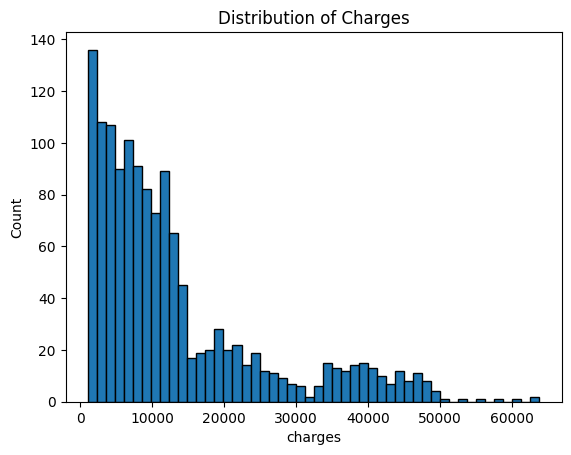

In [19]:
import matplotlib.pyplot as plt

plt.hist(df['charges'], bins=50, edgecolor='black')

plt.xlabel('charges')
plt.ylabel('Count')
plt.title('Distribution of Charges')

plt.show()

####  Scatterplot are between Age vs Charges

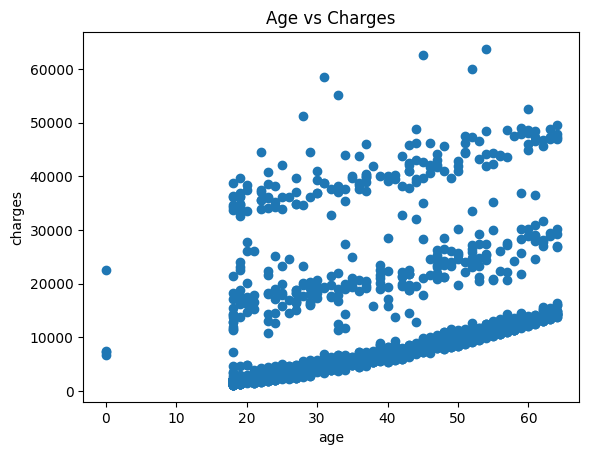

In [31]:
plt.scatter(df['age'],df['charges'])

plt.xlabel('age')
plt.ylabel('charges')
plt.title('Age vs Charges')

plt.show()

#### Scatterplot between bmi vs Charges

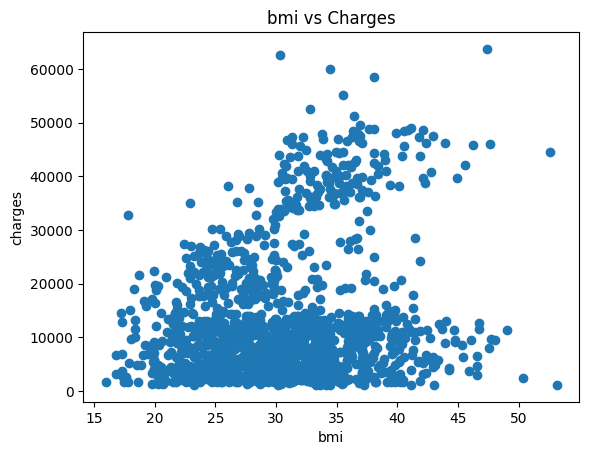

In [32]:
plt.scatter(df['bmi'],df['charges'])

plt.xlabel('bmi')
plt.ylabel('charges')
plt.title('bmi vs Charges')

plt.show()

#### Boxplot check relation b/w smoker vs charges

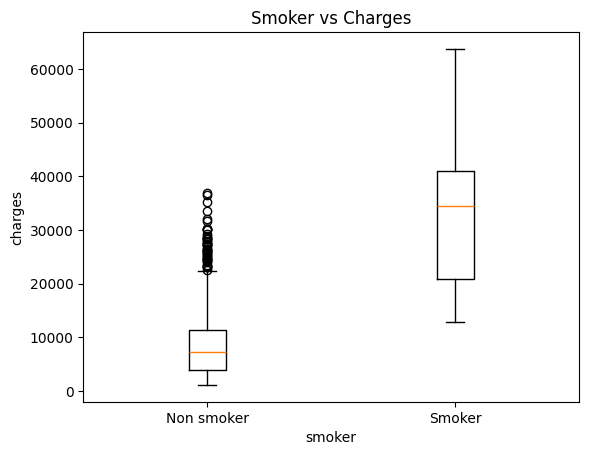

In [33]:
plt.boxplot([
    df[df['smoker'] == 0]['charges'],
    df[df['smoker'] == 1]['charges']
])
plt.xticks([1,2],['Non smoker', 'Smoker'])
plt.xlabel('smoker')
plt.ylabel('charges')
plt.title('Smoker vs Charges')
plt.show()

In [34]:
X = df.drop(columns = ['charges'])
y = df['charges']

In [35]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,1,3
1,18,2,33.770,1,0,4
2,28,2,33.000,3,0,4
3,33,2,22.705,0,0,1
4,32,2,28.880,0,0,1


In [36]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

#### train_test_split the data

In [37]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size= 0.2,random_state = 42)

In [38]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1072, 6)
(269, 6)
(1072,)
(269,)


#### pick model linearRegression

In [39]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

#### train the data

In [40]:
model.fit(X_train ,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### predict the data

In [41]:
y_pred = model.predict(X_test)

In [42]:
print(y_pred[:10])

[29278.00997087  3829.13948228  5287.34766586  3428.50037766
 26829.9937915   4763.74764781  6857.69128929 25605.64379964
  4698.42278109 10059.25507279]


In [43]:
print(y_test[:10].values)

[38792.6856   3213.62205  3761.292   23082.95533 33750.2918  20177.67113
  8605.3615  32548.3405   4661.28635  8310.83915]


#### Calculate r2

In [44]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print("R2 Score:",r2)

R2 Score: 0.7659239258692287


#### check  mean_absolute_error, mean_squared_error and Root Mean Squared Error

In [45]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 4460.150191794135
Mean Squared Error: 41559960.873169005
Root Mean Squared Error: 6446.701549875642


#### Scatter plot between Actual vs Predicted Charges

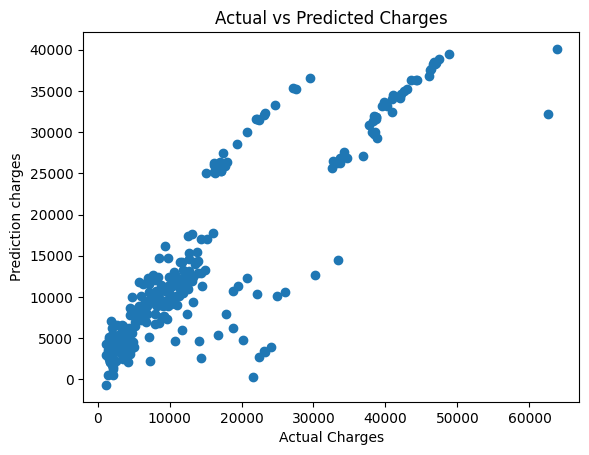

In [46]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Charges')
plt.ylabel('Prediction charges')
plt.title('Actual vs Predicted Charges')
plt.show()

In [47]:
import os

os.makedirs('models', exist_ok=True)

In [48]:
import pickle 
pickle.dump(model,open('models/linear_regression.pkl', 'wb'))
print("Model saved successfully!")

Model saved successfully!


#### New person pediction 

In [49]:
new_person = [[30,1,25.5,2,0,3]]

In [50]:
prediction = model.predict(new_person)
print("Predicted charges for the new person:", prediction[0])

Predicted charges for the new person: 4632.053738450644


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
